In [8]:
import pandas as pd


data = pd.read_csv('data/RNA-Seq-expression-Norilsk2019.csv')

In [63]:
data

,Gene,Species,log_2 fold change,Adjusted p-value
0,ENSG00000181577,homo sapiens,-6.8,6.395631e-214
1,ENSG00000128322,homo sapiens,-6.0,5.979922e-32
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00
3,ENSG00000148600,homo sapiens,-5.8,7.926548e-166
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84
...,...,...,...,...
995,ENSG00000137221,homo sapiens,1.7,5.994751e-72
996,ENSG00000092020,homo sapiens,1.7,3.487785e-71
997,ENSG00000089195,homo sapiens,1.7,8.793077e-71
998,ENSG00000179832,homo sapiens,-1.7,9.521317e-71


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Asumiendo que tu DataFrame se llama "data"
df = data.copy()

# Umbrales definidos
fc_threshold = 2  # Cambio de al menos 2^(1.5) ≈ 2.8 veces
pval_threshold = 0.05

# Clasificación
df['Significativo'] = 'No significativo'
df.loc[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sobre-expresado'
df.loc[(df['log_2 fold change'] <= -fc_threshold) & (df['Adjusted p-value'] < pval_threshold), 'Significativo'] = 'Sub-expresado'


In [11]:
genes_up = df[(df['log_2 fold change'] > 0) & (df['Significativo'] == 'Sobre-expresado')]
gene_ids = genes_up['Gene'].tolist()


In [64]:
genes_up

,Gene,Species,log_2 fold change,Adjusted p-value,Significativo
2,ENSG00000177606,homo sapiens,5.8,0.000000e+00,Sobre-expresado
4,ENSG00000164309,homo sapiens,5.6,1.625288e-84,Sobre-expresado
7,ENSG00000184545,homo sapiens,5.1,1.509396e-83,Sobre-expresado
13,ENSG00000085465,homo sapiens,4.3,2.881886e-114,Sobre-expresado
16,ENSG00000087589,homo sapiens,4.3,7.197535e-15,Sobre-expresado
...,...,...,...,...,...
650,ENSG00000276966,homo sapiens,2.0,8.746922e-03,Sobre-expresado
651,ENSG00000126787,homo sapiens,2.0,1.026658e-02,Sobre-expresado
652,ENSG00000064886,homo sapiens,2.0,1.414406e-02,Sobre-expresado
653,ENSG00000117281,homo sapiens,2.0,1.448692e-02,Sobre-expresado


In [ ]:
import pandas as pd

# Supongamos que ya tienes el DataFrame cargado como `data`

# Clasificar según el log2 fold change
sobre_exp = (data['log_2 fold change'] > 0).sum()   # Mayor a 0 → sobre-expresado
sub_exp = (data['log_2 fold change'] < 0).sum()     # Menor a 0 → sub-expresado
igual_cero = (data['log_2 fold change'] == 0).sum() # Por si hay genes sin cambio

print(f"Genes sobre-expresados: {sobre_exp}")
print(f"Genes sub-expresados: {sub_exp}")
print(f"Genes sin cambio (log2FC = 0): {igual_cero}")


Genes sobre-expresados: 447
Genes sub-expresados: 553
Genes sin cambio (log2FC = 0): 0


In [12]:
len(gene_ids)

265

In [13]:
import requests

string_api_url = "https://string-db.org/api"
output_format = "tsv-no-header"
method = "network"

# Reemplaza con tu lista de genes convertidos a símbolos si es necesario
genes_str = "%0d".join(gene_ids)  # formateo para múltiples genes

params = {
    "identifiers": genes_str,
    "species": 9606,  # Homo sapiens
    "caller_identity": "tu_nombre_o_correo"
}

response = requests.post(f"{string_api_url}/{output_format}/{method}", data=params)

# Guarda el archivo si es necesario o procesa directamente:
with open("string_interactions.tsv", "w") as f:
    f.write(response.text)


In [ ]:
response.text


In [14]:
import pandas as pd
import networkx as nx

# Cargar archivo STRING
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)
G = nx.Graph()

# Agrega nodos y aristas
for _, row in df_net.iterrows():
    G.add_edge(row[2], row[3], weight=row[5])  # ajusta columnas si es necesario


In [67]:
df_net

,prot1_id,prot2_id,gene1,gene2,taxon,neighb,fusion,cooc,coexp,exper,db,textmining,combined_score
0,9606.ENSP00000155093,9606.ENSP00000346986,ZFY,WAC,9606,0.418,0.0,0.000,0.252,0.000,0.046,0.00,0.250
1,9606.ENSP00000155093,9606.ENSP00000367203,ZFY,KDM6A,9606,0.457,0.0,0.000,0.000,0.087,0.117,0.00,0.381
2,9606.ENSP00000196489,9606.ENSP00000379464,ZNF416,ZNF134,9606,0.483,0.0,0.000,0.073,0.466,0.000,0.00,0.000
3,9606.ENSP00000206595,9606.ENSP00000499238,G2E3,NUSAP1,9606,0.449,0.0,0.000,0.000,0.243,0.000,0.00,0.302
4,9606.ENSP00000206595,9606.ENSP00000328228,G2E3,CDCA2,9606,0.580,0.0,0.000,0.000,0.180,0.000,0.00,0.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,9606.ENSP00000476136,9606.ENSP00000496044,H2BC11,POLR1C,9606,0.562,0.0,0.000,0.000,0.000,0.271,0.40,0.080
537,9606.ENSP00000476136,9606.ENSP00000497609,H2BC11,INO80,9606,0.824,0.0,0.000,0.000,0.000,0.821,0.00,0.057
538,9606.ENSP00000476136,9606.ENSP00000484789,H2BC11,H4C5,9606,0.981,0.0,0.065,0.000,0.444,0.915,0.54,0.204
539,9606.ENSP00000483430,9606.ENSP00000496832,IFI27,ISG15,9606,0.970,0.0,0.000,0.000,0.783,0.109,0.00,0.857


In [66]:
df_net.head(10)

,prot1_id,prot2_id,gene1,gene2,taxon,neighb,fusion,cooc,coexp,exper,db,textmining,combined_score
0,9606.ENSP00000155093,9606.ENSP00000346986,ZFY,WAC,9606,0.418,0.0,0.0,0.252,0.000,0.046,0.0,0.250
1,9606.ENSP00000155093,9606.ENSP00000367203,ZFY,KDM6A,9606,0.457,0.0,0.0,0.000,0.087,0.117,0.0,0.381
2,9606.ENSP00000196489,9606.ENSP00000379464,ZNF416,ZNF134,9606,0.483,0.0,0.0,0.073,0.466,0.000,0.0,0.000
3,9606.ENSP00000206595,9606.ENSP00000499238,G2E3,NUSAP1,9606,0.449,0.0,0.0,0.000,0.243,0.000,0.0,0.302
4,9606.ENSP00000206595,9606.ENSP00000328228,G2E3,CDCA2,9606,0.580,0.0,0.0,0.000,0.180,0.000,0.0,0.509
5,9606.ENSP00000206595,9606.ENSP00000247191,G2E3,DLGAP5,9606,0.600,0.0,0.0,0.000,0.285,0.000,0.0,0.464
6,9606.ENSP00000215631,9606.ENSP00000350633,GADD45B,SERTAD1,9606,0.536,0.0,0.0,0.000,0.461,0.000,0.0,0.174
7,9606.ENSP00000215631,9606.ENSP00000306245,GADD45B,FOS,9606,0.627,0.0,0.0,0.000,0.267,0.000,0.0,0.511
8,9606.ENSP00000215631,9606.ENSP00000448665,GADD45B,DDIT3,9606,0.644,0.0,0.0,0.000,0.150,0.000,0.0,0.599
9,9606.ENSP00000215631,9606.ENSP00000239223,GADD45B,DUSP1,9606,0.669,0.0,0.0,0.000,0.420,0.000,0.0,0.453


In [71]:
# Ordenar por combined_score (de mayor a menor) y tomar las 10 primeras interacciones
top10_interacciones = df_net.sort_values(by="combined_score", ascending=False).head(10)

print(top10_interacciones)


                 prot1_id              prot2_id   gene1   gene2  taxon  \
275  9606.ENSP00000306245  9606.ENSP00000360266     FOS     JUN   9606   
369  9606.ENSP00000344352  9606.ENSP00000360266    ATF3     JUN   9606   
30   9606.ENSP00000233630  9606.ENSP00000328004   PCGF1    YAF2   9606   
394  9606.ENSP00000349748  9606.ENSP00000359216    SFPQ   PTBP2   9606   
462  9606.ENSP00000362820  9606.ENSP00000436679   SRSF3    NXF1   9606   
26   9606.ENSP00000221452  9606.ENSP00000312988    RELB  NFKBIB   9606   
274  9606.ENSP00000306245  9606.ENSP00000344352     FOS    ATF3   9606   
367  9606.ENSP00000343966  9606.ENSP00000349748   PSPC1    SFPQ   9606   
117  9606.ENSP00000262367  9606.ENSP00000360266  CREBBP     JUN   9606   
16   9606.ENSP00000216489  9606.ENSP00000397673  ALKBH1  ALKBH8   9606   

     neighb  fusion  cooc  coexp  exper     db  textmining  combined_score  
275   0.999     0.0   0.0  0.000  0.690  0.999        0.90           0.999  
369   0.999     0.0   0.0  0.00

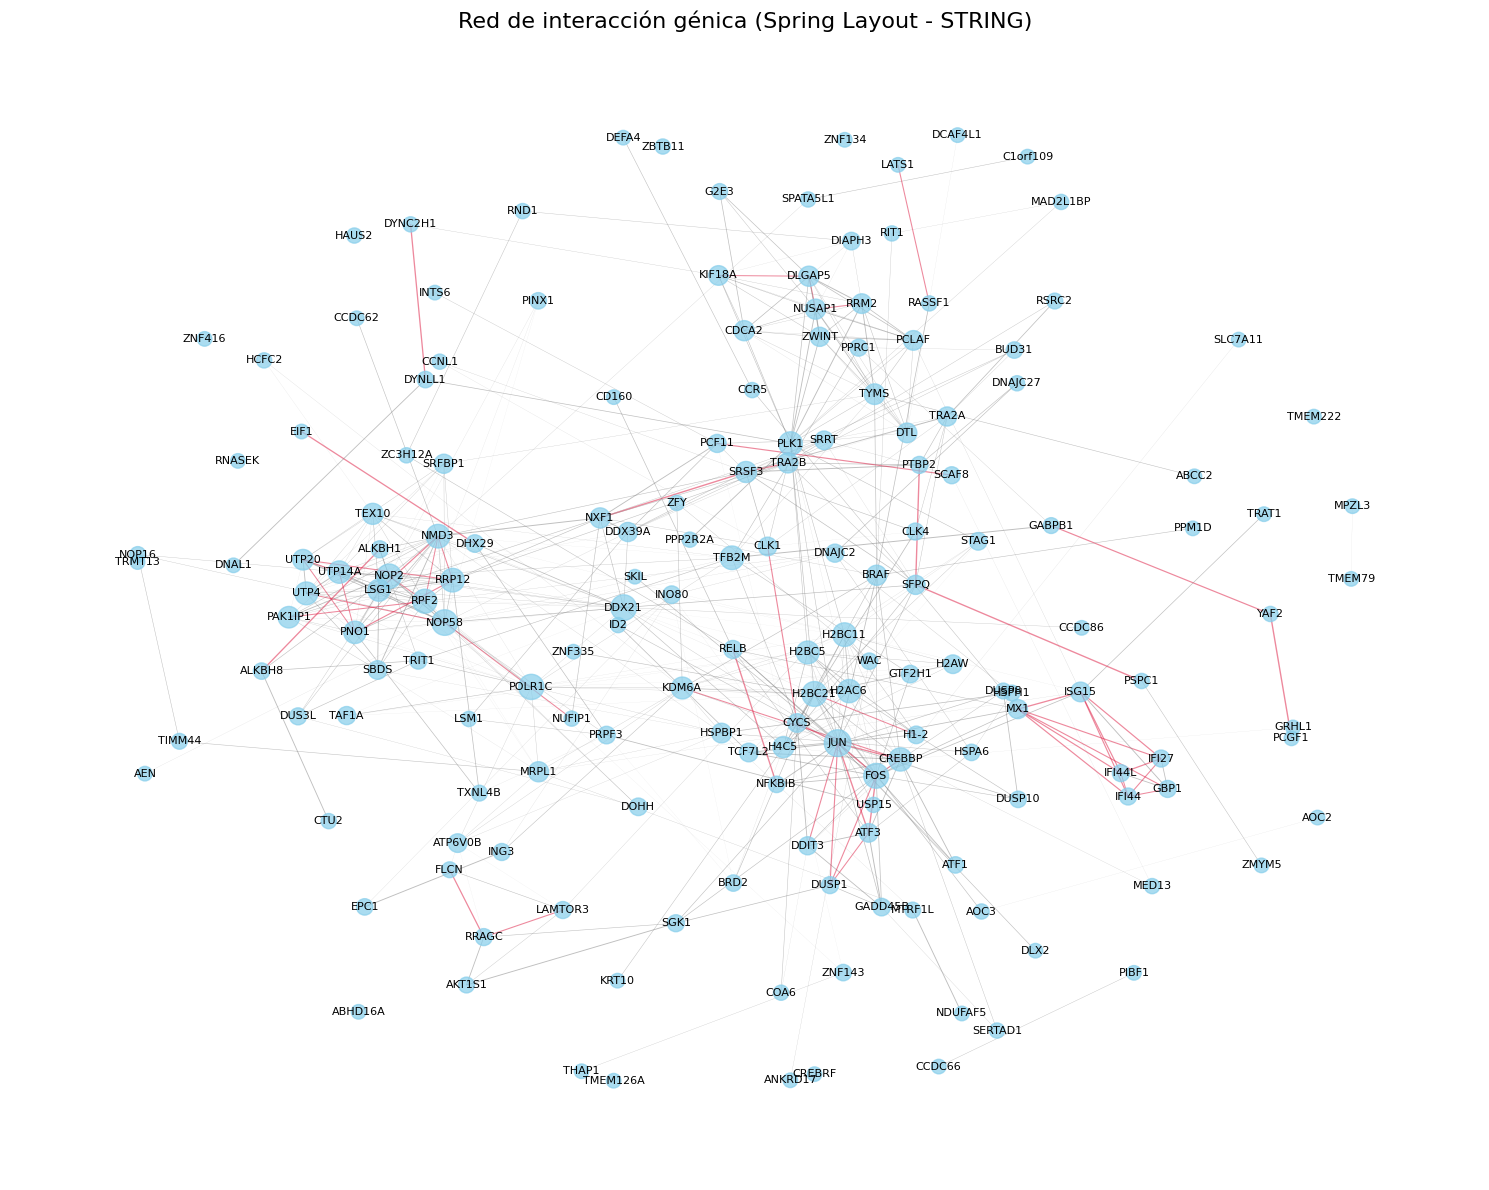

In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Cargar datos
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)

# Extraer columnas clave
df_net.columns = ['prot1_id', 'prot2_id', 'gene1', 'gene2', 'taxon', 'neighb', 'fusion', 'cooc', 'coexp', 'exper', 'db', 'textmining', 'combined_score']

# Crear grafo no dirigido con genes como nodos y peso como score combinado
G = nx.Graph()

for _, row in df_net.iterrows():
    G.add_edge(row['gene1'], row['gene2'], weight=row['combined_score'])

# Usar layout de fuerzas (Spring)
pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

# Tamaño de los nodos según su grado (número de conexiones)
node_sizes = [100 + 10*G.degree(n) for n in G.nodes()]

# Ancho de las aristas según el score
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_colors = ['gray' if w < 0.7 else 'crimson' for w in edge_weights]

# Visualización
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Red de interacción génica (Spring Layout - STRING)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


In [17]:
clustering_coef = nx.average_clustering(G)
print(f"Coeficiente de clustering promedio: {clustering_coef:.4f}")


Coeficiente de clustering promedio: 0.3378


In [18]:
grado_promedio = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Grado promedio: {grado_promedio:.2f}")


Grado promedio: 6.33


In [19]:
if nx.is_connected(G):
    avg_path_length = nx.average_shortest_path_length(G)
else:
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc)
    avg_path_length = nx.average_shortest_path_length(G_lcc)

print(f"Camino largo promedio: {avg_path_length:.2f}")


Camino largo promedio: 3.43


In [20]:
if nx.is_connected(G):
    geodesic = nx.diameter(G)
else:
    geodesic = nx.diameter(G_lcc)

print(f"Geodésica (diámetro): {geodesic}")


Geodésica (diámetro): 8


In [21]:
# Es lo mismo que:
print(f"Diámetro: {geodesic}")


Diámetro: 8


In [14]:
from itertools import combinations

n = G.number_of_nodes()
total_pairs = n * (n - 1) / 2

# Contar pares conectados
reachable_pairs = 0
for u, v in combinations(G.nodes, 2):
    if nx.has_path(G, u, v):
        reachable_pairs += 1

prob_conectividad = reachable_pairs / total_pairs
print(f"Probabilidad de conectividad: {prob_conectividad:.4f}")


Probabilidad de conectividad: 0.9649


In [5]:
if nx.is_connected(G):
    max_len = 0
    path_geodesico = []
    for n1 in G.nodes():
        for n2 in G.nodes():
            try:
                path = nx.shortest_path(G, n1, n2)
                if len(path) > max_len:
                    max_len = len(path)
                    path_geodesico = path
            except nx.NetworkXNoPath:
                continue
    print("Nodos en la geodésica:", path_geodesico)


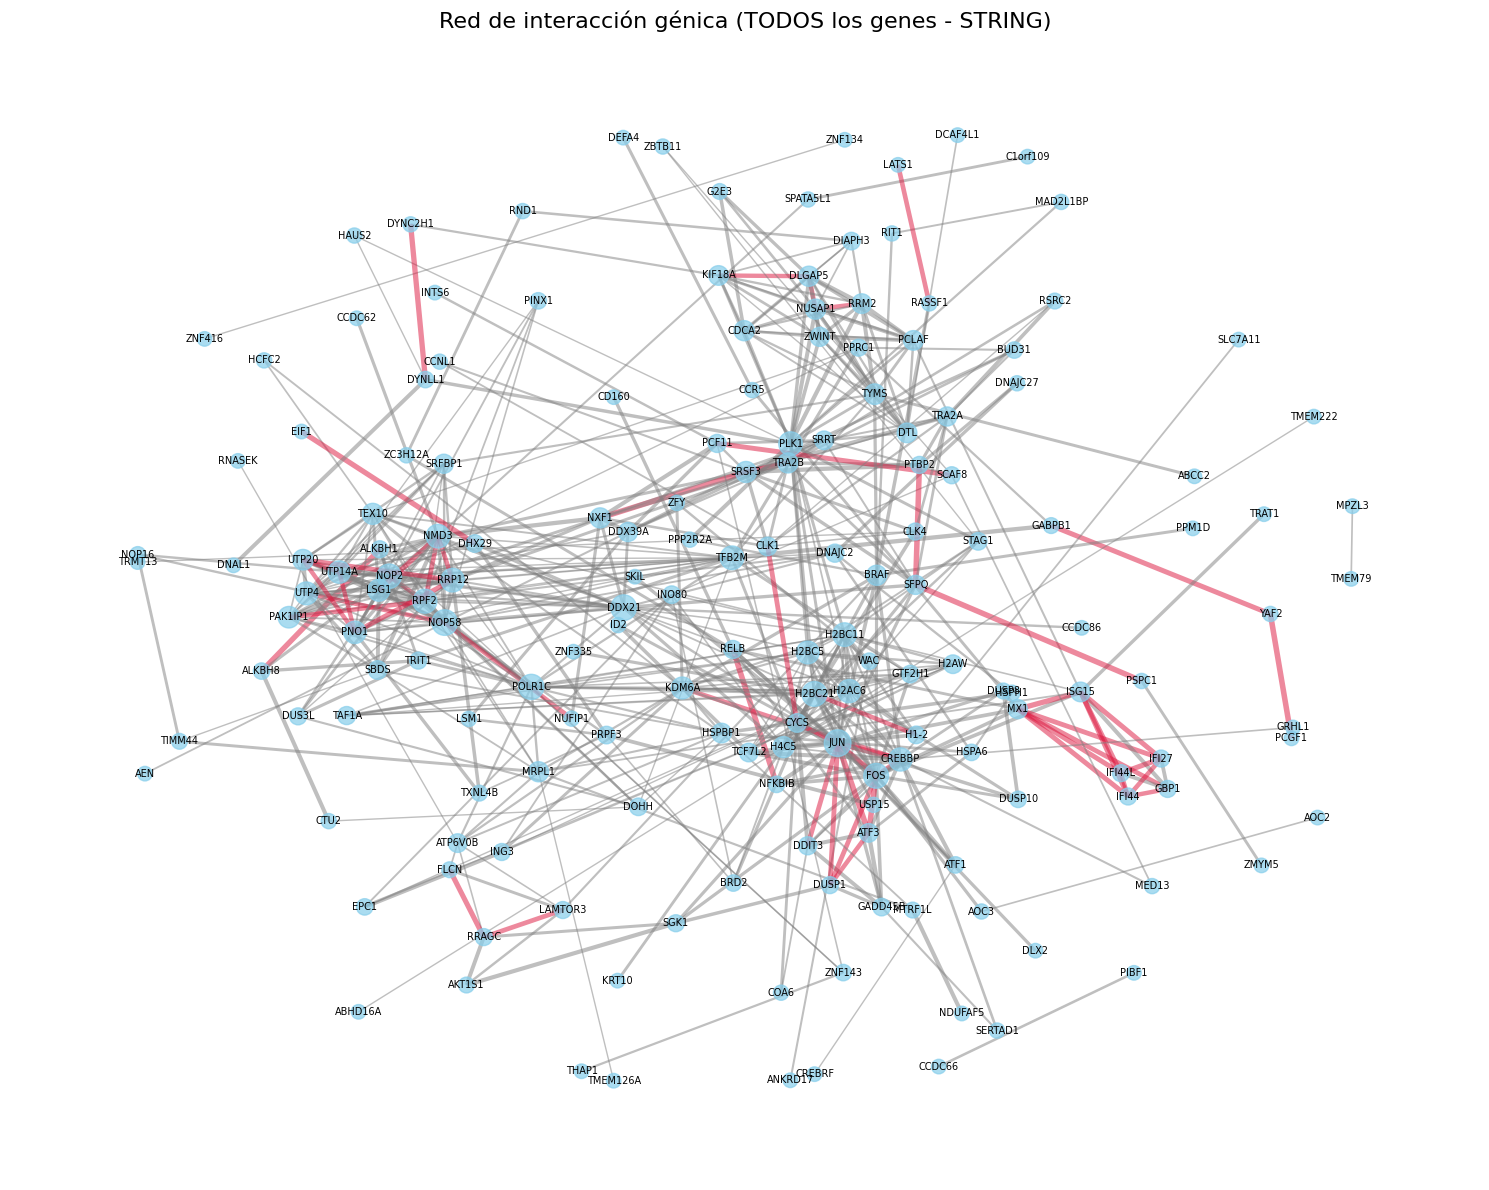

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Cargar datos
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)
df_net.columns = ['prot1_id', 'prot2_id', 'gene1', 'gene2', 'taxon',
                  'neighb', 'fusion', 'cooc', 'coexp',
                  'exper', 'db', 'textmining', 'combined_score']

# Grafo completo
G = nx.Graph()
for _, row in df_net.iterrows():
    G.add_edge(row['gene1'], row['gene2'], weight=row['combined_score'])

# Layout
pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

# Tamaño de nodos (según grado)
node_sizes = [100 + 10*G.degree(n) for n in G.nodes()]

# Ancho de aristas (escalado para mejor visibilidad)
edge_weights = [1 + 3*G[u][v]['weight'] for u, v in G.edges()]

# Color de aristas (rojas = interacciones fuertes)
edge_colors = ['gray' if G[u][v]['weight'] < 0.7 else 'crimson' for u, v in G.edges()]

# Visualización
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color=edge_colors, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=7)

plt.title("Red de interacción génica (TODOS los genes - STRING)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_genica_completa.png", dpi=300)
plt.show()


Geodésica (diámetro 8 pasos): ['PCGF1', 'YAF2', 'GABPB1', 'TFB2M', 'CYCS', 'JUN', 'SFPQ', 'PSPC1', 'ZMYM5']


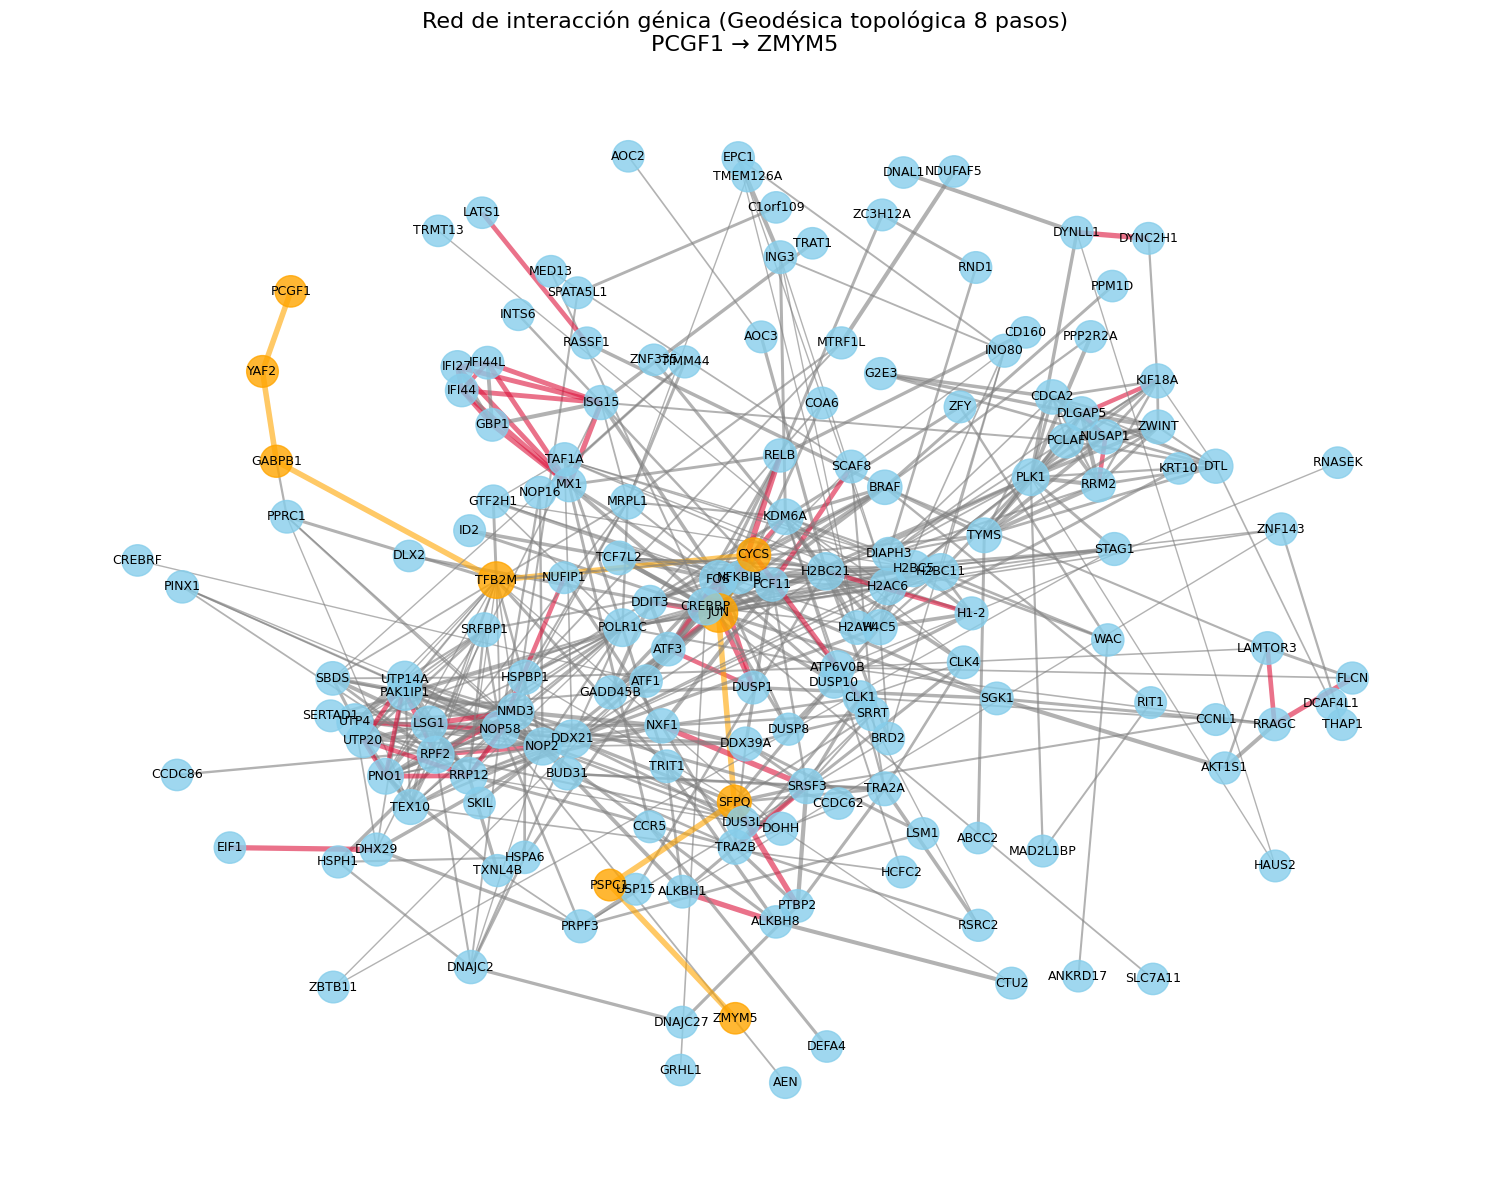

In [56]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==============================
# 1. Cargar datos de STRING
# ==============================
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)
df_net.columns = ['prot1_id', 'prot2_id', 'gene1', 'gene2', 'taxon',
                  'neighb', 'fusion', 'cooc', 'coexp',
                  'exper', 'db', 'textmining', 'combined_score']

# ==============================
# 2. Construir grafo (ignorando pesos para la geodésica)
# ==============================
G = nx.Graph()
for _, row in df_net.iterrows():
    G.add_edge(row['gene1'], row['gene2'], weight=row['combined_score'])

# ==============================
# 3. Mantener solo el componente conexo más grande
# ==============================
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()
else:
    G_lcc = G

# ==============================
# 4. Calcular la geodésica TOPOLOGICA (sin pesos)
# ==============================
diameter = nx.diameter(G_lcc)  # nº de pasos del camino más largo
periphery_nodes = nx.periphery(G_lcc)  # nodos más alejados

# Tomamos un par cualquiera de la periferia y calculamos su camino más corto
u = periphery_nodes[0]
v = periphery_nodes[-1]
geodesic_path = nx.shortest_path(G_lcc, source=u, target=v)

print(f"Geodésica (diámetro {diameter} pasos): {geodesic_path}")

# ==============================
# 5. Preparar atributos para graficar
# ==============================
pos = nx.spring_layout(G_lcc, k=0.5, iterations=100, seed=42)

# Tamaño de nodos (grado)
node_sizes = [500 + 10 * G_lcc.degree(n) for n in G_lcc.nodes()]

# Color de nodos (naranja si están en la geodésica)
node_colors = ['orange' if n in geodesic_path else 'skyblue' for n in G_lcc.nodes()]

# Color y grosor de aristas
geodesic_edges = list(zip(geodesic_path, geodesic_path[1:]))
edge_colors = []
edge_weights = []

for u, v in G_lcc.edges():
    if (u, v) in geodesic_edges or (v, u) in geodesic_edges:
        edge_colors.append('orange')   # Resaltamos aristas de la geodésica
        edge_weights.append(4)         # Más gruesas
    else:
        # Aún podemos resaltar interacciones fuertes para el resto de la red
        edge_colors.append('crimson' if G_lcc[u][v]['weight'] >= 0.7 else 'gray')
        edge_weights.append(1 + 3 * G_lcc[u][v]['weight'])

# ==============================
# 6. Visualización
# ==============================
plt.figure(figsize=(15, 12))
nx.draw_networkx_nodes(G_lcc, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G_lcc, pos, width=edge_weights, edge_color=edge_colors, alpha=0.6)
nx.draw_networkx_labels(G_lcc, pos, font_size=9)

plt.title(f"Red de interacción génica (Geodésica topológica {diameter} pasos)\n"
          f"{geodesic_path[0]} → {geodesic_path[-1]}",
          fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_genica_geodesica_topologica.png", dpi=300)
plt.show()


In [72]:
print(f"Número de nodos en la red (componente más grande): {G_lcc.number_of_nodes()}")
print(f"Número de aristas en la red: {G_lcc.number_of_edges()}")


Número de nodos en la red (componente más grande): 163
Número de aristas en la red: 537


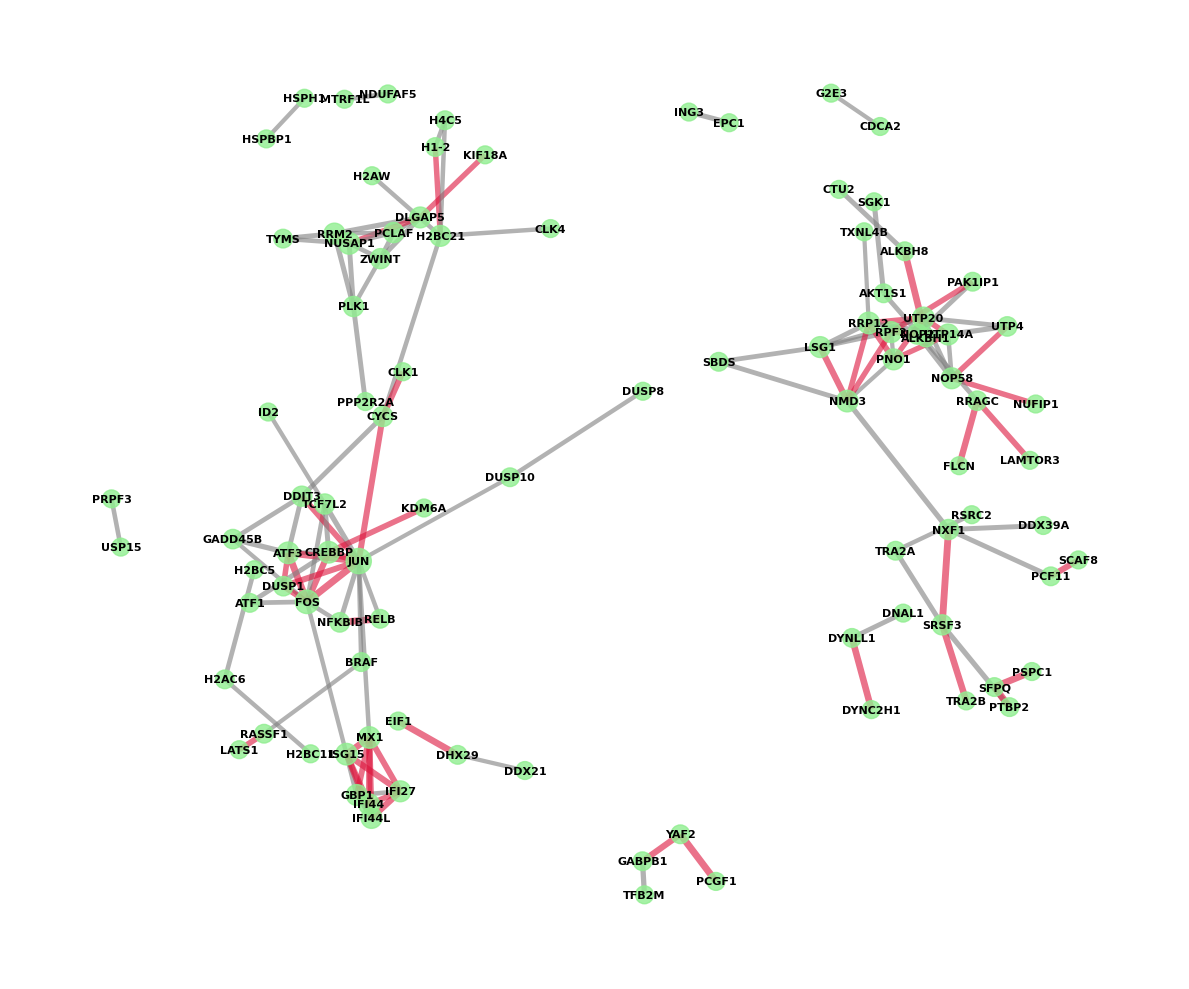

In [87]:
# Filtrar solo interacciones fuertes
df_strong = df_net[df_net['combined_score'] >= 0.5]

# Crear grafo solo con esas interacciones
G_strong = nx.Graph()
for _, row in df_strong.iterrows():
    G_strong.add_edge(row['gene1'], row['gene2'], weight=row['combined_score'])

# Mantener solo genes con al menos 5 interacciones (para grafo más interpretable)
genes_high_degree = [n for n, d in G_strong.degree() if d >= 1]
H = G_strong.subgraph(genes_high_degree)

# Layout
pos = nx.spring_layout(H, k=0.4, iterations=100, seed=42)

# Tamaño de nodos y ancho de aristas
node_sizes = [150 + 15*H.degree(n) for n in H.nodes()]
edge_weights = [1 + 4*H[u][v]['weight'] for u, v in H.edges()]
edge_colors = ['crimson' if H[u][v]['weight'] > 0.7 else 'gray' for u, v in H.edges()]

# Visualización
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color='lightgreen', alpha=0.8)
nx.draw_networkx_edges(H, pos, width=edge_weights, edge_color=edge_colors, alpha=0.6)
nx.draw_networkx_labels(H, pos, font_size=8, font_weight='bold')

plt.title("", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_genica_filtrada.png", dpi=300)
plt.show()


In [27]:
genes_high_degree

['GADD45B',
 'FOS',
 'DDIT3',
 'ATF3',
 'NOP2',
 'JUN',
 'NFKBIB',
 'TCF7L2',
 'DUSP1',
 'NXF1',
 'LSG1',
 'NMD3',
 'DLGAP5',
 'PCLAF',
 'ZWINT',
 'RRM2',
 'NUSAP1',
 'UTP20',
 'RRP12',
 'PNO1',
 'UTP14A',
 'NOP58',
 'UTP4',
 'CREBBP',
 'RPF2',
 'RRAGC',
 'SRSF3',
 'PLK1',
 'ISG15',
 'CYCS',
 'H2BC21',
 'GBP1',
 'IFI27',
 'IFI44L',
 'IFI44',
 'MX1']

Geodésica (diámetro 8 pasos): ['PCGF1', 'YAF2', 'GABPB1', 'TFB2M', 'CYCS', 'JUN', 'SFPQ', 'PSPC1', 'ZMYM5']


C:\Users\felip\AppData\Local\Temp\ipykernel_40512\3752596844.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


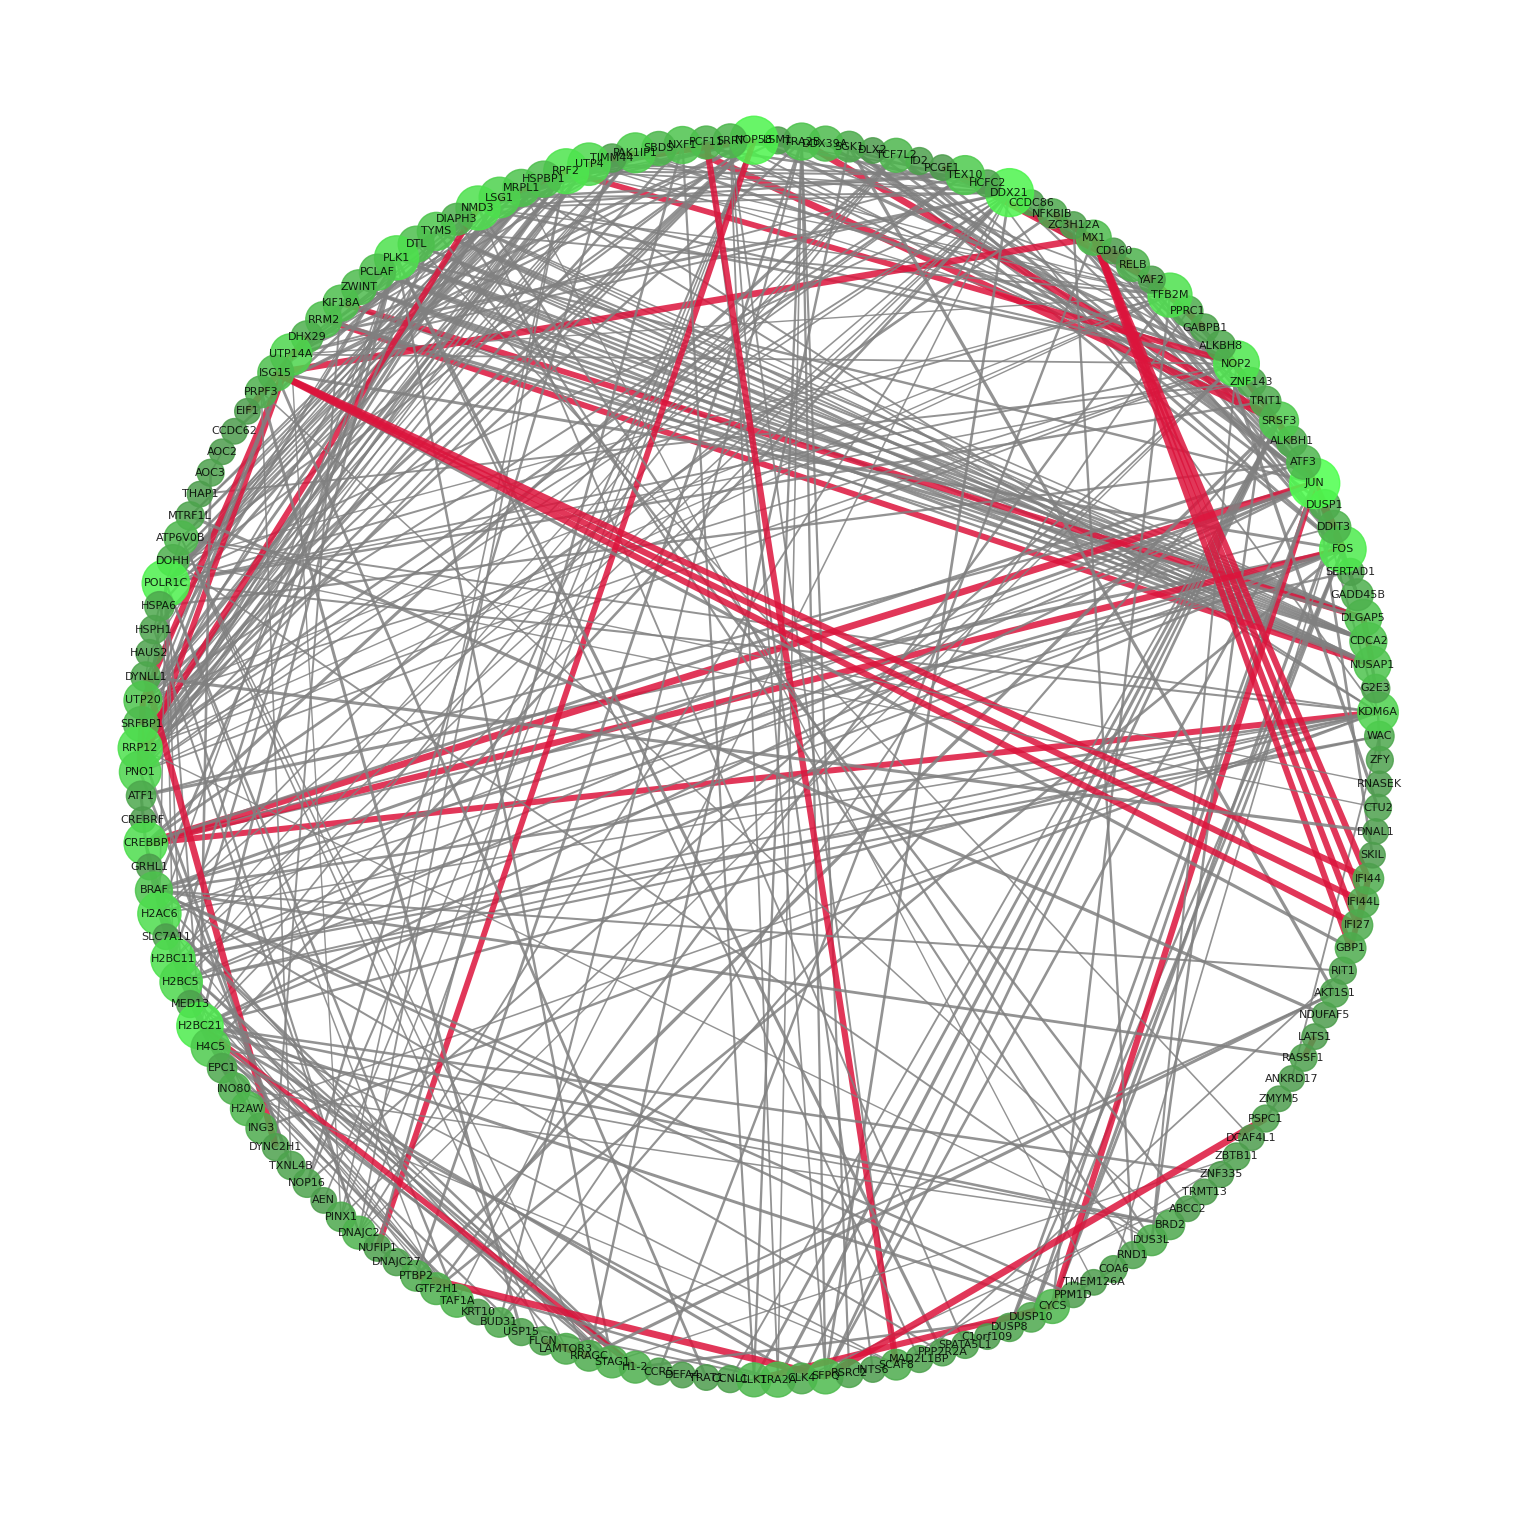

In [103]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==============================
# 1. Cargar datos
# ==============================
df_net = pd.read_csv("string_interactions.tsv", sep="\t", header=None)
df_net.columns = ['prot1_id', 'prot2_id', 'gene1', 'gene2', 'taxon',
                  'neighb', 'fusion', 'cooc', 'coexp',
                  'exper', 'db', 'textmining', 'combined_score']

# ==============================
# 2. Construir grafo (SIN pesos para geodésica)
# ==============================
G = nx.Graph()
for _, row in df_net.iterrows():
    G.add_edge(row['gene1'], row['gene2'], weight=row['combined_score'])

# Mantener solo el componente conexo más grande
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()
else:
    G_lcc = G

# ==============================
# 3. Calcular geodésica (DIÁMETRO TOPOLOGICO)
# ==============================
diameter = nx.diameter(G_lcc)  # número de pasos del camino más largo
periphery_nodes = nx.periphery(G_lcc)

u = periphery_nodes[0]
v = periphery_nodes[-1]
geodesic_path = nx.shortest_path(G_lcc, source=u, target=v)

print(f"Geodésica (diámetro {diameter} pasos): {geodesic_path}")

# ==============================
# 4. Layout circular y atributos
# ==============================
pos = nx.circular_layout(G_lcc)

# --- Tamaño de nodos proporcional al grado
max_degree = max(dict(G_lcc.degree()).values())
node_sizes = [300 + 1000 * (G_lcc.degree(n) / max_degree) for n in G_lcc.nodes()]

# --- Color de nodos (naranja si están en la geodésica, verde oscuro para hubs)
node_colors = []
for n in G_lcc.nodes():

    intensity = G_lcc.degree(n) / max_degree
    node_colors.append((0.3, 0.6 + 0.4*intensity, 0.3))  # Verde más intenso en hubs

# --- Color y grosor de aristas (manteniendo pesos solo para visualización)
geodesic_edges = list(zip(geodesic_path, geodesic_path[1:]))

edge_colors = []
edge_widths = []
for u, v in G_lcc.edges():
    
    if G_lcc[u][v]['weight'] >= 0.7:
        edge_colors.append('crimson')
        edge_widths.append(2 + 3 * G_lcc[u][v]['weight'])
    else:
        edge_colors.append('gray')
        edge_widths.append(1 + 2 * G_lcc[u][v]['weight'])

# ==============================
# 5. Visualización
# ==============================
plt.figure(figsize=(15, 15))
nx.draw(
    G_lcc,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=node_sizes,
    width=edge_widths,
    font_size=8,
    alpha=0.85
)

plt.title("", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("red_genica_circular_geodesica_topologica.png", dpi=300)
plt.show()


In [29]:
import networkx as nx

# Si la red no es conexa, trabajar con el componente conexo más grande
if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc).copy()
else:
    G_lcc = G

# Encontrar todos los pares con distancias mínimas
lengths = dict(nx.all_pairs_shortest_path_length(G_lcc))

# Buscar la mayor distancia y el par asociado
max_len = 0
geodesic_pair = (None, None)

for u in G_lcc.nodes():
    for v in G_lcc.nodes():
        if u != v and lengths[u][v] > max_len:
            max_len = lengths[u][v]
            geodesic_pair = (u, v)

# Obtener el camino geodésico entre los dos nodos más distantes
geodesic_path = nx.shortest_path(G_lcc, source=geodesic_pair[0], target=geodesic_pair[1])
print(f"Geodésica ({max_len} pasos): {geodesic_path}")


Geodésica (8 pasos): ['PCGF1', 'YAF2', 'GABPB1', 'TFB2M', 'GTF2H1', 'FOS', 'MX1', 'CCR5', 'DEFA4']


In [30]:
import mygene

mg = mygene.MyGeneInfo()

# Filtrar genes sobre-expresados
genes_up = df[(df['log_2 fold change'] >= fc_threshold) & (df['Adjusted p-value'] < pval_threshold)]
gene_ids = genes_up['Gene'].tolist()

# Consulta a MyGene
results = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol,name,go', species='human')

# Convertir a DataFrame
go_df = pd.DataFrame(results)

# Filtrar y mostrar columnas relevantes
go_df = go_df[['query', 'symbol', 'name', 'go']]
go_df.head()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
6 input query terms found dup hits:	[('ENSG00000137959', 4), ('ENSG00000165949', 4), ('ENSG00000137965', 3), ('ENSG00000187608', 2), ('E


,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [31]:
# go_df tiene columnas: query, symbol, name, go
go_df.head()


,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [96]:
go_df

,query,symbol,name,go
0,ENSG00000177606,JUN,"Jun proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IDA', 'gocategory': 'BP'..."
1,ENSG00000164309,CMYA5,cardiomyopathy associated 5,"{'CC': [{'evidence': 'IEA', 'gocategory': 'CC'..."
2,ENSG00000184545,DUSP8,dual specificity phosphatase 8,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
3,ENSG00000085465,OVGP1,oviductal glycoprotein 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
4,ENSG00000087589,CASS4,Cas scaffold protein family member 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
...,...,...,...,...
260,ENSG00000276966,H4C5,H4 clustered histone 5,"{'BP': [{'evidence': 'NAS', 'gocategory': 'BP'..."
261,ENSG00000126787,DLGAP5,DLG associated protein 5,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
262,ENSG00000064886,CHI3L2,chitinase 3 like 2,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
263,ENSG00000117281,CD160,CD160 molecule,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [32]:
# Anotar nodos que están en el camino geodésico
anotacion_geodesica = go_df[go_df['symbol'].isin(geodesic_path)].copy()
anotacion_geodesica = anotacion_geodesica[['symbol', 'name', 'go']]
print(anotacion_geodesica)


     symbol                                               name  \
61      FOS  Fos proto-oncogene, AP-1 transcription factor ...   
65   GTF2H1         general transcription factor IIH subunit 1   
71    TFB2M             transcription factor B2, mitochondrial   
128  GABPB1  GA binding protein transcription factor subuni...   
159    CCR5                     C-C motif chemokine receptor 5   
224    YAF2                            YY1 associated factor 2   
236   PCGF1                       polycomb group ring finger 1   
255     MX1                           MX dynamin like GTPase 1   
257     MX1                           MX dynamin like GTPase 1   
259   DEFA4                                   defensin alpha 4   

                                                    go  
61   {'BP': [{'evidence': 'IEA', 'gocategory': 'BP'...  
65   {'BP': [{'evidence': 'TAS', 'gocategory': 'BP'...  
71   {'BP': [{'evidence': 'IEA', 'gocategory': 'BP'...  
128  {'BP': [{'evidence': 'IEA', 'gocategory'

In [33]:
anotacion_geodesica

,symbol,name,go
61,FOS,"Fos proto-oncogene, AP-1 transcription factor ...","{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
65,GTF2H1,general transcription factor IIH subunit 1,"{'BP': [{'evidence': 'TAS', 'gocategory': 'BP'..."
71,TFB2M,"transcription factor B2, mitochondrial","{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
128,GABPB1,GA binding protein transcription factor subuni...,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
159,CCR5,C-C motif chemokine receptor 5,"{'BP': [{'evidence': 'IEP', 'gocategory': 'BP'..."
224,YAF2,YY1 associated factor 2,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
236,PCGF1,polycomb group ring finger 1,"{'BP': [{'evidence': 'IBA', 'gocategory': 'BP'..."
255,MX1,MX dynamin like GTPase 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
257,MX1,MX dynamin like GTPase 1,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."
259,DEFA4,defensin alpha 4,"{'BP': [{'evidence': 'IEA', 'gocategory': 'BP'..."


In [34]:
from mygene import MyGeneInfo
mg = MyGeneInfo()

converted = mg.querymany(gene_ids, scopes='ensembl.gene', fields='symbol', species='human')
symbols = [item['symbol'] for item in converted if 'symbol' in item]


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


6 input query terms found dup hits:	[('ENSG00000137959', 4), ('ENSG00000165949', 4), ('ENSG00000137965', 3), ('ENSG00000187608', 2), ('E


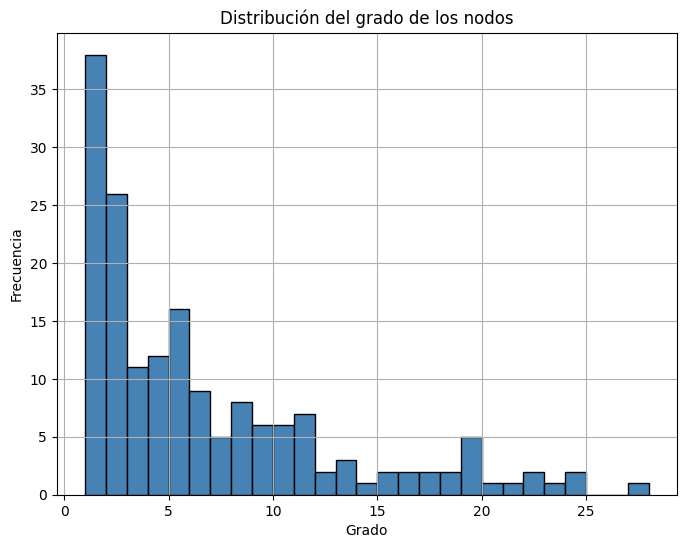

In [35]:
import matplotlib.pyplot as plt

degrees = [deg for _, deg in G.degree()]
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=range(1, max(degrees)+2), color='steelblue', edgecolor='black')
plt.title("Distribución del grado de los nodos")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


In [81]:
# 5 genes con mayor log2 fold change (ENSG)
top5_ensg = genes_up.sort_values("log_2 fold change", ascending=False).head(5)["Gene"].tolist()

# Mapeo ENSG → símbolo
map_ensg_symbol = go_df.set_index("query")["symbol"].to_dict()

# Convertimos los ENSG a símbolos
top5_symbols = [map_ensg_symbol.get(g) for g in top5_ensg if g in map_ensg_symbol]
print("Top 5 genes sobre-expresados (símbolos):", top5_symbols)


Top 5 genes sobre-expresados (símbolos): ['JUN', 'CMYA5', 'DUSP8', 'CASS4', 'OVGP1']


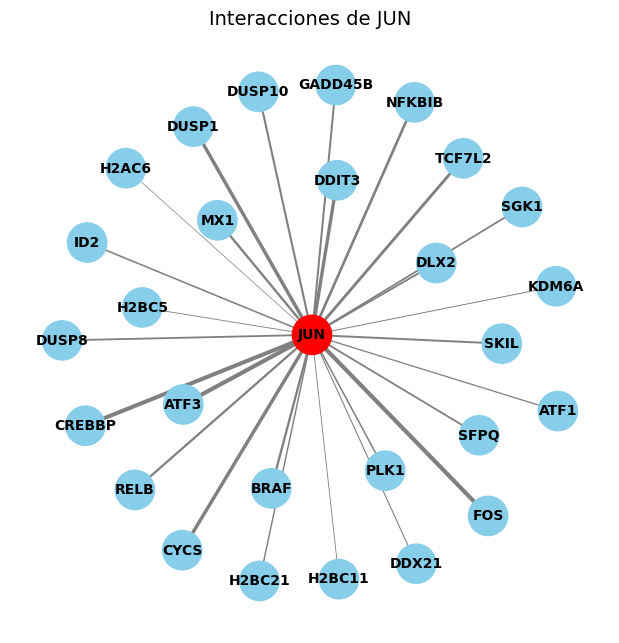

No se encontraron interacciones para CMYA5


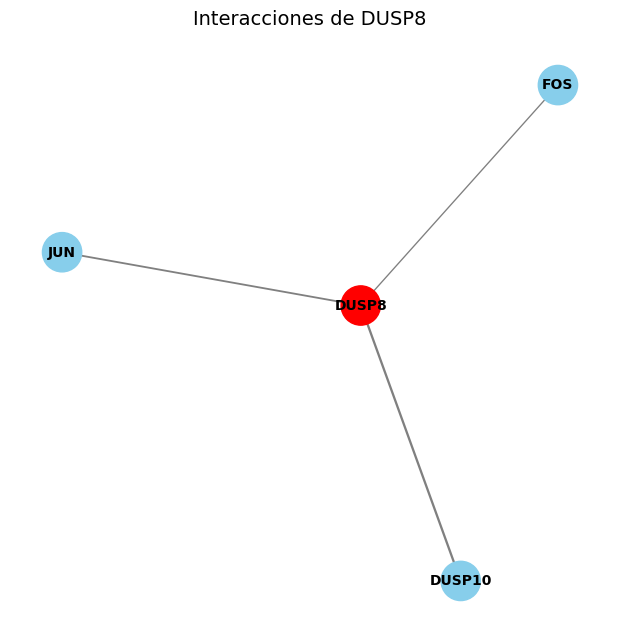

No se encontraron interacciones para CASS4
No se encontraron interacciones para OVGP1


In [82]:
import networkx as nx
import matplotlib.pyplot as plt

for gen in top5_symbols:
    # Filtrar interacciones donde participa el gen
    df_gen = df_net[(df_net["gene1"] == gen) | (df_net["gene2"] == gen)]
    
    if df_gen.empty:
        print(f"No se encontraron interacciones para {gen}")
        continue

    # Crear grafo
    G = nx.from_pandas_edgelist(
        df_gen,
        source="gene1",
        target="gene2",
        edge_attr="combined_score"
    )
    
    # Colorear el gen de interés en rojo, el resto en celeste
    color_map = ["red" if node == gen else "skyblue" for node in G.nodes()]
    
    # Dibujar con grosor proporcional al combined_score
    edges = G.edges(data=True)
    widths = [max(attr["combined_score"] * 3, 0.5) for _, _, attr in edges]  # grosor

    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=color_map,
        node_size=800,
        font_size=10,
        font_weight="bold",
        edge_color="gray",
        width=widths
    )
    plt.title(f"Interacciones de {gen}", fontsize=14)
    plt.show()


In [88]:
import networkx as nx

# Crear grafo no dirigido (STRING normalmente es no dirigido)
G = nx.from_pandas_edgelist(df_net, 'gene1', 'gene2')

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
    

Número de nodos: 171
Número de aristas: 541


In [89]:
# Lista de nodos aislados
nodos_aislados = list(nx.isolates(G))

if nodos_aislados:
    print("Nodos aislados encontrados:", nodos_aislados)
else:
    print("No hay nodos aislados")


No hay nodos aislados


In [90]:
# Componentes conexos (subredes)
componentes = list(nx.connected_components(G))
print(f"Número de subredes (componentes conexos): {len(componentes)}")

# Tamaño de cada componente
for i, comp in enumerate(componentes, 1):
    print(f"Componente {i}: {len(comp)} nodos")


Número de subredes (componentes conexos): 5
Componente 1: 163 nodos
Componente 2: 2 nodos
Componente 3: 2 nodos
Componente 4: 2 nodos
Componente 5: 2 nodos


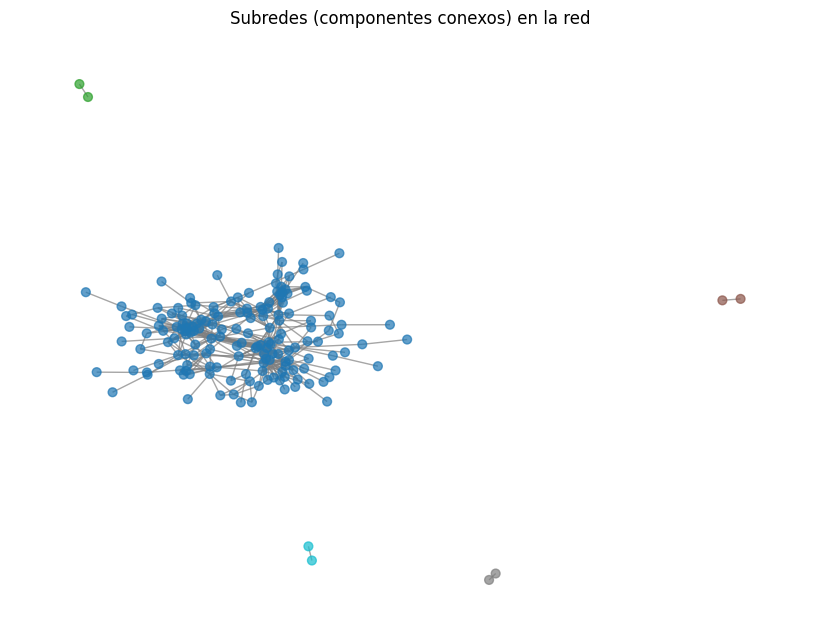

In [91]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear el grafo (ya lo tienes)
G = nx.from_pandas_edgelist(df_net, 'gene1', 'gene2')

# Obtener componentes conexos
componentes = list(nx.connected_components(G))

# Asignar un color distinto a cada componente
color_map = {}
for i, comp in enumerate(componentes):
    for node in comp:
        color_map[node] = i  # identificador de componente

# Generar lista de colores para cada nodo en el grafo
node_colors = [color_map[n] for n in G.nodes()]

# Layout y dibujo
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=False,  # pon True si quieres ver nombres
    node_size=40,
    node_color=node_colors,
    cmap=plt.cm.tab10,  # paleta de 10 colores
    edge_color="gray",
    alpha=0.7
)
plt.title("Subredes (componentes conexos) en la red")
plt.show()


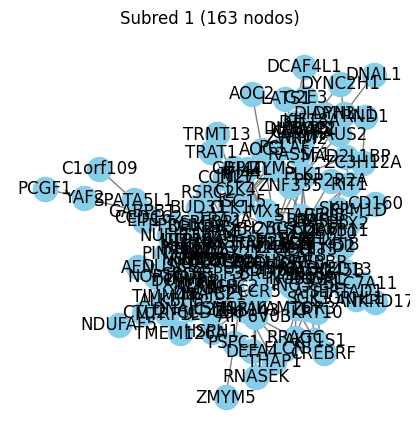

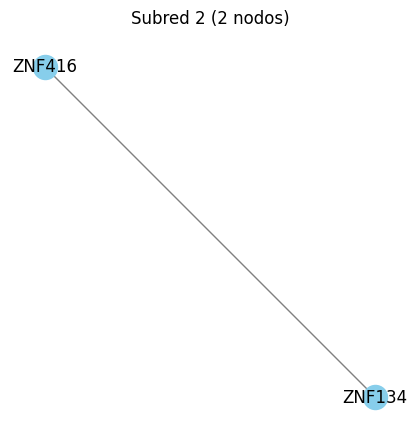

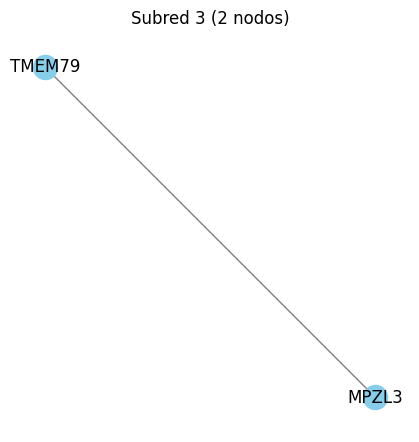

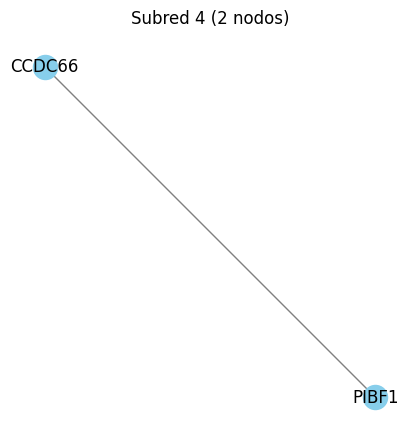

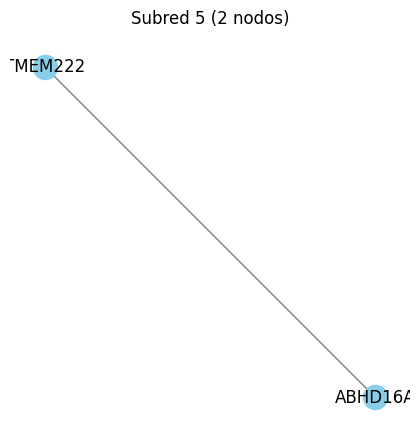

In [92]:
for i, comp in enumerate(componentes, 1):
    subG = G.subgraph(comp)
    
    plt.figure(figsize=(4, 4))
    pos = nx.spring_layout(subG, seed=42)
    nx.draw(
        subG, pos,
        with_labels=True,
        node_size=300,
        node_color="skyblue",
        edge_color="gray"
    )
    plt.title(f"Subred {i} ({len(comp)} nodos)")
    plt.show()


Top 5 genes con más conexiones: ['JUN', 'DDX21', 'NOP58', 'POLR1C', 'FOS']


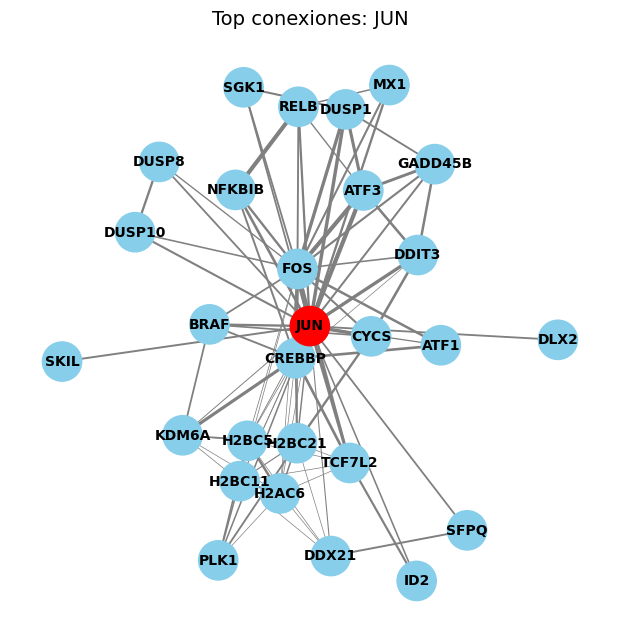

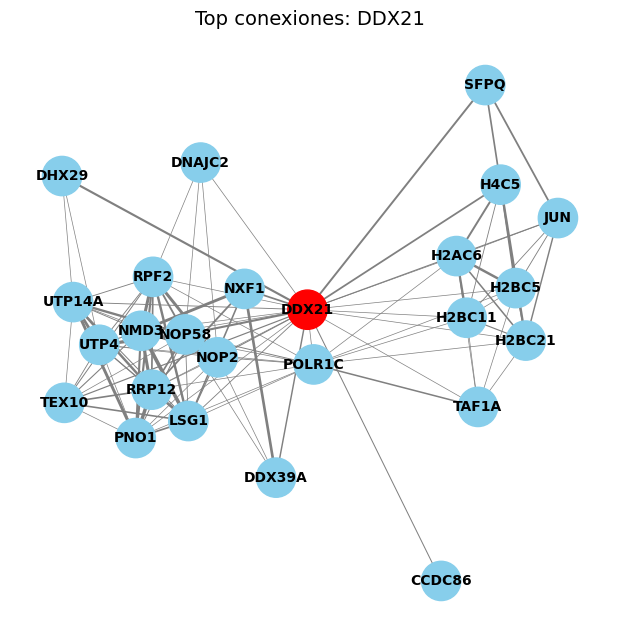

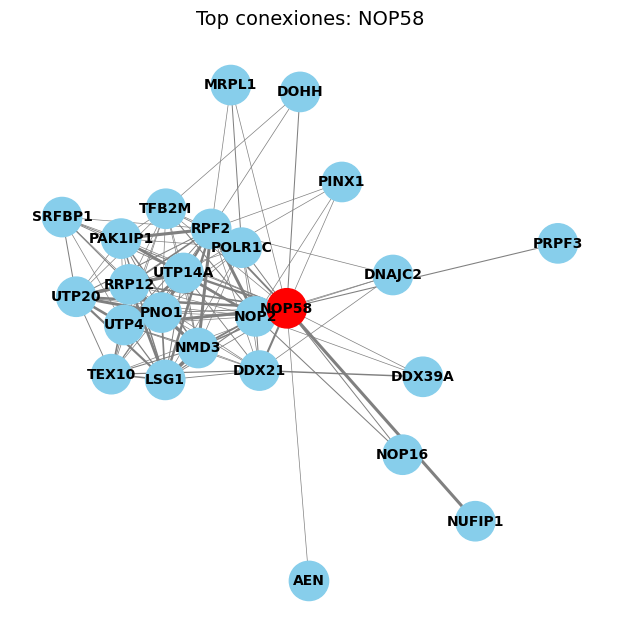

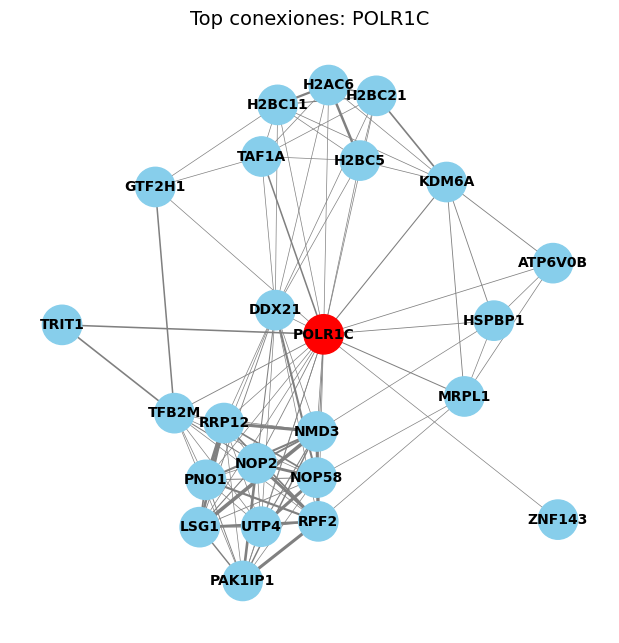

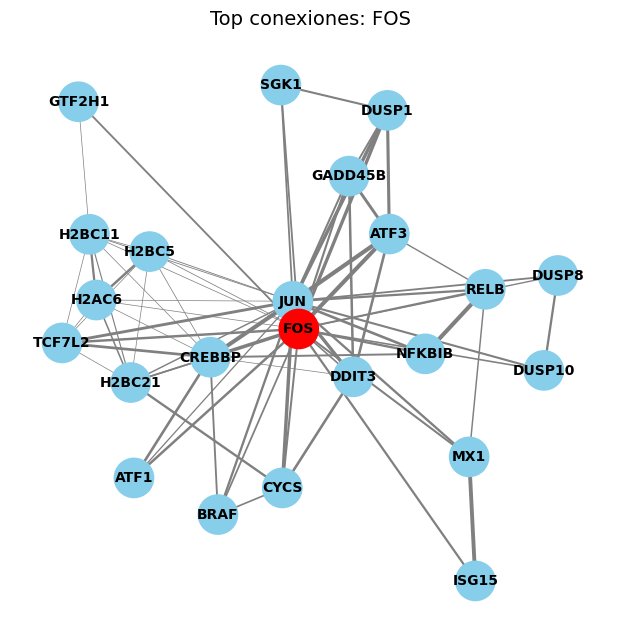

In [93]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo completo a partir de df_net
G_full = nx.from_pandas_edgelist(
    df_net,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

# Calcular grado de cada gen
degree_dict = dict(G_full.degree())
top5_by_degree = sorted(degree_dict, key=degree_dict.get, reverse=True)[:5]
print("Top 5 genes con más conexiones:", top5_by_degree)

# Generar 5 figuras (una por cada gen)
for gen in top5_by_degree:
    neighbors = list(G_full.neighbors(gen))
    sub_nodes = [gen] + neighbors
    G_sub = G_full.subgraph(sub_nodes)
    
    color_map = ["red" if node == gen else "skyblue" for node in G_sub.nodes()]
    widths = [max(attr["combined_score"] * 3, 0.5) for _, _, attr in G_sub.edges(data=True)]
    
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw(
        G_sub, pos,
        with_labels=True,
        node_color=color_map,
        node_size=800,
        font_size=10,
        font_weight="bold",
        edge_color="gray",
        width=widths
    )
    plt.title(f"Top conexiones: {gen}", fontsize=14)
    plt.show()


Top 5 genes con conexiones más fuertes: ['JUN', 'FOS', 'H2BC21', 'NMD3', 'NOP58']


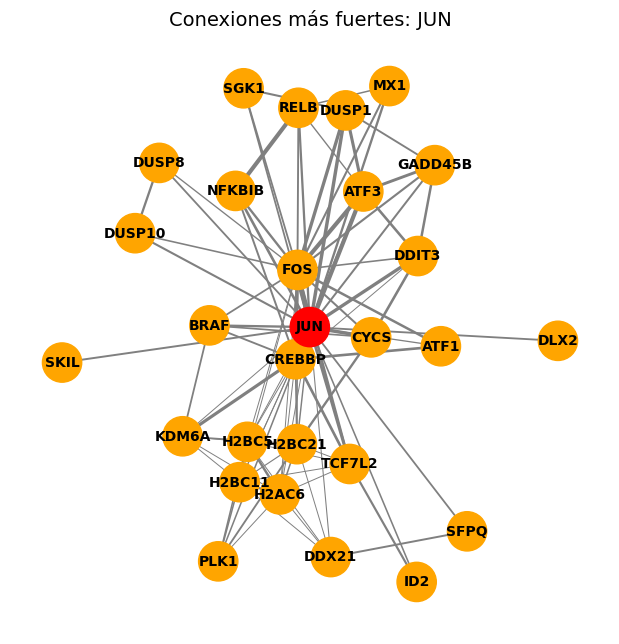

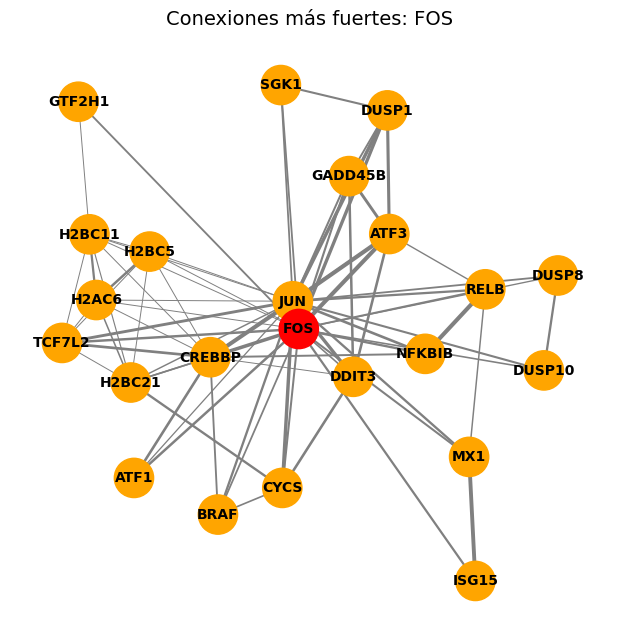

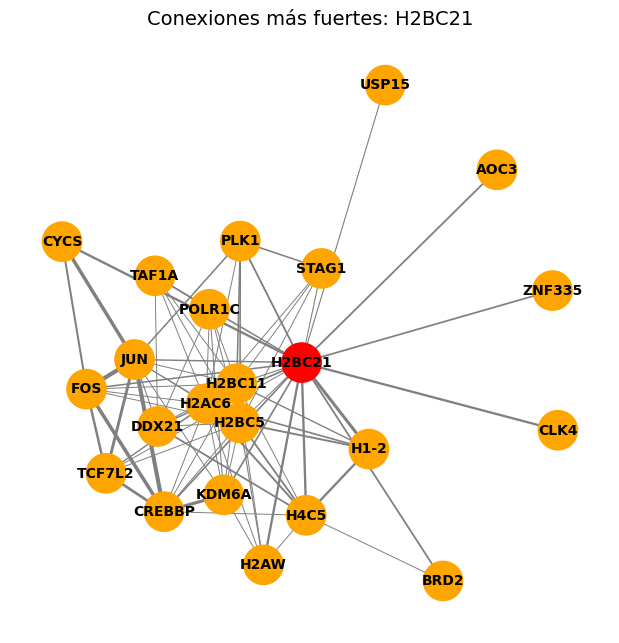

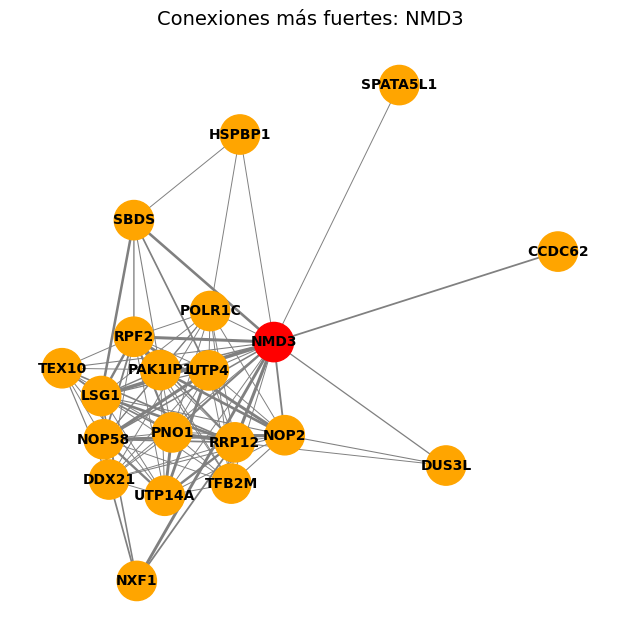

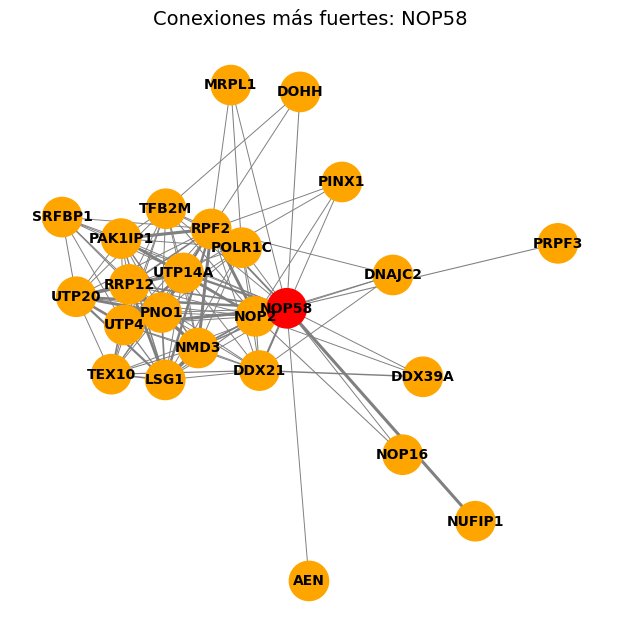

In [95]:
# Calcular la "fuerza total" de conexión por gen
strength_dict = {}
for u, v, data in G_full.edges(data=True):
    strength_dict[u] = strength_dict.get(u, 0) + data["combined_score"]
    strength_dict[v] = strength_dict.get(v, 0) + data["combined_score"]

top5_by_strength = sorted(strength_dict, key=strength_dict.get, reverse=True)[:5]
print("Top 5 genes con conexiones más fuertes:", top5_by_strength)

# Generar 5 figuras (una por cada gen)
for gen in top5_by_strength:
    neighbors = list(G_full.neighbors(gen))
    sub_nodes = [gen] + neighbors
    G_sub = G_full.subgraph(sub_nodes)
    
    color_map = ["red" if node == gen else "orange" for node in G_sub.nodes()]
    widths = [max(attr["combined_score"] * 3, 0.7) for _, _, attr in G_sub.edges(data=True)]
    
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw(
        G_sub, pos,
        with_labels=True,
        node_color=color_map,
        node_size=800,
        font_size=10,
        font_weight="bold",
        edge_color="gray",
        width=widths
    )
    plt.title(f"Conexiones más fuertes: {gen}", fontsize=14)
    plt.show()


In [ ]:
log_2 fold change

In [99]:
# 1. Buscar en go_df el query correspondiente a NOP58
nop58_query = go_df.loc[go_df['symbol'] == 'NOP58', 'query'].values[0]
print("Query de NOP58:", nop58_query)

# 2. Buscar en genes_up el log2 fold change usando la columna 'Gene'
log2fc_nop58 = genes_up.loc[genes_up['Gene'] == 'ENSG00000055044', 'log_2 fold change'].values[0]
print("log2 Fold Change de NOP58:", log2fc_nop58)


Query de NOP58: ENSG00000055044
log2 Fold Change de NOP58: 2.1


In [ ]:
# 1. Buscar en go_df el query correspondiente a NOP58
nop58_query = go_df.loc[go_df['symbol'] == 'NMD3', 'query'].values[0]
print("Query de NOP58:", nop58_query)

# 2. Buscar en genes_up el log2 fold change usando la columna 'Gene'
log2fc_nop58 = genes_up.loc[genes_up['Gene'] == 'ENSG00000169251', 'log_2 fold change'].values[0]
print("log2 Fold Change de NMD3:", log2fc_nop58)


Query de NOP58: ENSG00000169251
log2 Fold Change de NOP58: 2.0
